In [ ]:
!pip install -q -U transformers accelerate torch pandas matplotlib huggingface_hub

import os, re, json, time, textwrap, warnings
from pathlib import Path
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import torch
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline

warnings.filterwarnings("ignore")

MODEL_ID = "openai/privacy-filter"
OUT_DIR = Path("/content/privacy_filter_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

device = 0 if torch.cuda.is_available() else -1
torch_dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32

print("Device:", "GPU" if torch.cuda.is_available() else "CPU")
print("Torch dtype:", torch_dtype)
print("Model:", MODEL_ID)

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_ID,
    torch_dtype=torch_dtype,
    device_map="auto" if torch.cuda.is_available() else None
)

classifier = pipeline(
    task="token-classification",
    model=model,
    tokenizer=tokenizer,
    aggregation_strategy="simple",
    device=device if not torch.cuda.is_available() else None
)

LABEL_MASKS = {
    "account_number": "[ACCOUNT_NUMBER]",
    "private_address": "[PRIVATE_ADDRESS]",
    "private_email": "[PRIVATE_EMAIL]",
    "private_person": "[PRIVATE_PERSON]",
    "private_phone": "[PRIVATE_PHONE]",
    "private_url": "[PRIVATE_URL]",
    "private_date": "[PRIVATE_DATE]",
    "secret": "[SECRET]"
}

In [ ]:
def normalize_label(label):
    label = label.replace("B-", "").replace("I-", "").replace("E-", "").replace("S-", "")
    return label.strip()

def detect_pii(text):
    raw = classifier(text)
    spans = []
    for item in raw:
        label = normalize_label(item.get("entity_group", item.get("entity", "")))
        if label == "O" or not label:
            continue
        spans.append({
            "label": label,
            "score": float(item["score"]),
            "text": item["word"],
            "start": int(item["start"]),
            "end": int(item["end"])
        })
    spans = sorted(spans, key=lambda x: (x["start"], x["end"]))
    return spans

def redact_text(text, spans, min_score=0.50, mode="typed"):
    filtered = [s for s in spans if s["score"] >= min_score]
    filtered = sorted(filtered, key=lambda x: x["start"], reverse=True)
    redacted = text
    for span in filtered:
        replacement = LABEL_MASKS.get(span["label"], "[PII]") if mode == "typed" else "[REDACTED]"
        redacted = redacted[:span["start"]] + replacement + redacted[span["end"]:]
    return redacted

def privacy_report(text, min_score=0.50):
    spans = detect_pii(text)
    redacted = redact_text(text, spans, min_score=min_score)
    return {
        "original_text": text,
        "redacted_text": redacted,
        "span_count": len([s for s in spans if s["score"] >= min_score]),
        "spans": [s for s in spans if s["score"] >= min_score]
    }

In [ ]:
sample_texts = [
    "My name is Alice Smith and my email is alice.smith@example.com. Call me at +1 415 555 0189.",
    "Patient Rohan Mehta visited on 2025-04-11 and lives at 221B Baker Street, London.",
    "Use API key sk-test-51HxYzDemoSecret987 and send the invoice to billing@acme.ai.",
    "The public website is https://example.com, but Jane Doe's private portal is https://jane-private.example.net.",
    "Account number 123456789012 was linked to Ahmed Khan on 12 March 2024.",
    "This sentence has no private information and should mostly remain unchanged."
]

reports = []
for i, text in enumerate(sample_texts, 1):
    report = privacy_report(text, min_score=0.50)
    report["example_id"] = i
    reports.append(report)

for r in reports:
    print("\n" + "=" * 100)
    print("Example:", r["example_id"])
    print("Original:", r["original_text"])
    print("Redacted:", r["redacted_text"])
    print("Detected spans:")
    print(json.dumps(r["spans"], indent=2, ensure_ascii=False))

rows = []
for r in reports:
    for s in r["spans"]:
        rows.append({
            "example_id": r["example_id"],
            "label": s["label"],
            "score": s["score"],
            "detected_text": s["text"],
            "start": s["start"],
            "end": s["end"],
            "original_text": r["original_text"],
            "redacted_text": r["redacted_text"]
        })

df = pd.DataFrame(rows)
display(df)

In [ ]:
json_path = OUT_DIR / "privacy_filter_reports.json"
csv_path = OUT_DIR / "privacy_filter_spans.csv"

with open(json_path, "w", encoding="utf-8") as f:
    json.dump(reports, f, indent=2, ensure_ascii=False)

df.to_csv(csv_path, index=False)

print("\nSaved JSON:", json_path)
print("Saved CSV:", csv_path)

if len(df):
    label_counts = df["label"].value_counts()
    plt.figure(figsize=(10, 5))
    label_counts.plot(kind="bar")
    plt.title("Detected PII Categories")
    plt.xlabel("PII Category")
    plt.ylabel("Detected Span Count")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    df["score"].plot(kind="hist", bins=10)
    plt.title("Detection Confidence Distribution")
    plt.xlabel("Confidence Score")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

def compare_thresholds(text, thresholds=(0.30, 0.50, 0.70, 0.90)):
    spans = detect_pii(text)
    results = []
    for threshold in thresholds:
        kept = [s for s in spans if s["score"] >= threshold]
        results.append({
            "threshold": threshold,
            "span_count": len(kept),
            "redacted_text": redact_text(text, spans, min_score=threshold)
        })
    return pd.DataFrame(results)

threshold_demo = compare_thresholds(sample_texts[0])
display(threshold_demo)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 82.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/27.9M [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.80G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/140 [00:00<?, ?it/s]


Example: 1
Original: My name is Alice Smith and my email is alice.smith@example.com. Call me at +1 415 555 0189.
Redacted: My name is[PRIVATE_PERSON][PRIVATE_PERSON] and my email is[PRIVATE_EMAIL][PRIVATE_EMAIL]. Call me at[PRIVATE_PHONE][PRIVATE_PHONE].
Detected spans:
[
  {
    "label": "private_person",
    "score": 0.9999982118606567,
    "text": " Alice",
    "start": 10,
    "end": 16
  },
  {
    "label": "private_person",
    "score": 0.9999986886978149,
    "text": " Smith",
    "start": 16,
    "end": 22
  },
  {
    "label": "private_email",
    "score": 0.9999945163726807,
    "text": " alice.smith@example",
    "start": 38,
    "end": 58
  },
  {
    "label": "private_email",
    "score": 0.9999983310699463,
    "text": ".com",
    "start": 58,
    "end": 62
  },
  {
    "label": "private_phone",
    "score": 0.9999811053276062,
    "text": " +1 415 555 018",
    "start": 74,
    "end": 89
  },
  {
    "label": "private_phone",
    "score": 0.9999898672103882,
    "text":

,example_id,label,score,detected_text,start,end,original_text,redacted_text
0,1,private_person,0.999998,Alice,10,16,My name is Alice Smith and my email is alice.s...,My name is[PRIVATE_PERSON][PRIVATE_PERSON] and...
1,1,private_person,0.999999,Smith,16,22,My name is Alice Smith and my email is alice.s...,My name is[PRIVATE_PERSON][PRIVATE_PERSON] and...
2,1,private_email,0.999995,alice.smith@example,38,58,My name is Alice Smith and my email is alice.s...,My name is[PRIVATE_PERSON][PRIVATE_PERSON] and...
3,1,private_email,0.999998,.com,58,62,My name is Alice Smith and my email is alice.s...,My name is[PRIVATE_PERSON][PRIVATE_PERSON] and...
4,1,private_phone,0.999981,+1 415 555 018,74,89,My name is Alice Smith and my email is alice.s...,My name is[PRIVATE_PERSON][PRIVATE_PERSON] and...
5,1,private_phone,0.999990,9,89,90,My name is Alice Smith and my email is alice.s...,My name is[PRIVATE_PERSON][PRIVATE_PERSON] and...
6,2,private_person,0.999999,Rohan Me,7,16,Patient Rohan Mehta visited on 2025-04-11 and ...,Patient[PRIVATE_PERSON][PRIVATE_PERSON] visite...
7,2,private_person,0.999997,hta,16,19,Patient Rohan Mehta visited on 2025-04-11 and ...,Patient[PRIVATE_PERSON][PRIVATE_PERSON] visite...
8,2,private_date,0.999953,2025-04-,31,39,Patient Rohan Mehta visited on 2025-04-11 and ...,Patient[PRIVATE_PERSON][PRIVATE_PERSON] visite...
9,2,private_date,0.999991,11,39,41,Patient Rohan Mehta visited on 2025-04-11 and ...,Patient[PRIVATE_PERSON][PRIVATE_PERSON] visite...



Saved JSON: /content/privacy_filter_outputs/privacy_filter_reports.json
Saved CSV: /content/privacy_filter_outputs/privacy_filter_spans.csv


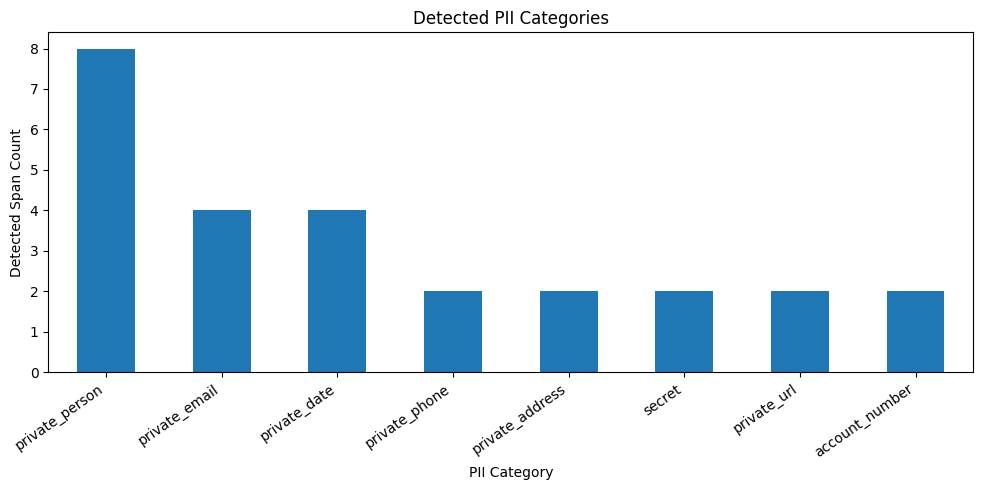

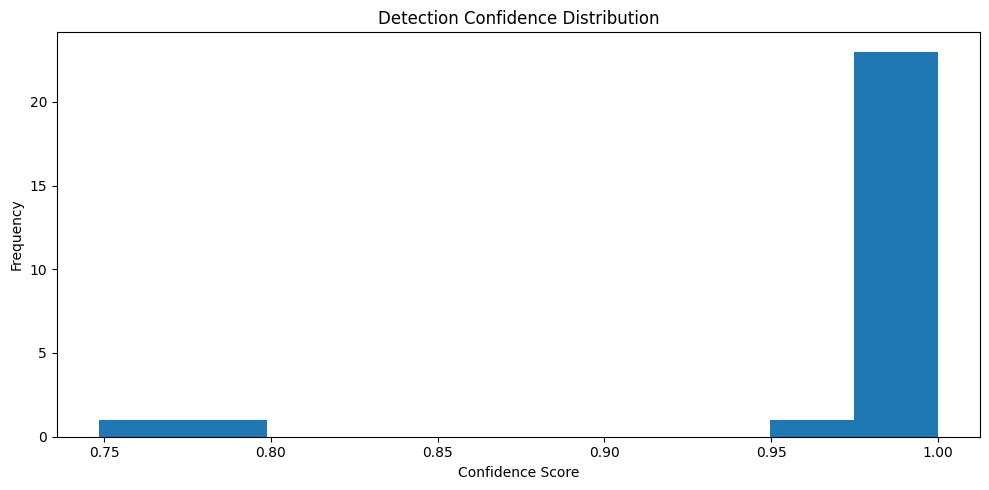

,threshold,span_count,redacted_text
0,0.3,6,My name is[PRIVATE_PERSON][PRIVATE_PERSON] and...
1,0.5,6,My name is[PRIVATE_PERSON][PRIVATE_PERSON] and...
2,0.7,6,My name is[PRIVATE_PERSON][PRIVATE_PERSON] and...
3,0.9,6,My name is[PRIVATE_PERSON][PRIVATE_PERSON] and...



LONG DOCUMENT REDACTION

Customer Support Transcript:
Agent: Hello, may I confirm your name?
Customer: My name is[PRIVATE_PERSON][PRIVATE_PERSON].
Agent: Thanks. Could you confirm your email?
Customer:[PRIVATE_EMAIL][PRIVATE_EMAIL].
Agent: And your phone number?
Customer:[PRIVATE_PHONE][PRIVATE_PHONE].
Agent: Your service address is [PRIVATE_ADDRESS][PRIVATE_ADDRESS].
Customer: Yes. Also, my backup email is[PRIVATE_EMAIL][PRIVATE_EMAIL].
Agent: Please do not share passwords or OTPs.
Customer: The temporary token I received is[SECRET][SECRET].


Structured spans:
[
  {
    "label": "private_person",
    "score": 0.9999974370002747,
    "text": " Priya",
    "start": 89,
    "end": 95
  },
  {
    "label": "private_person",
    "score": 0.9999959468841553,
    "text": " Sharma",
    "start": 95,
    "end": 102
  },
  {
    "label": "private_email",
    "score": 0.9999971389770508,
    "text": " priya.sharma1994@gmail",
    "start": 158,
    "end": 181
  },
  {
    "label": "private_emai

,id,original_chars,redacted_chars,span_count,labels_found,redacted_text
0,1,91,131,6,"{'private_person': 2, 'private_email': 2, 'pri...",My name is[PRIVATE_PERSON][PRIVATE_PERSON] and...
1,2,81,127,6,"{'private_person': 2, 'private_date': 2, 'priv...",Patient[PRIVATE_PERSON][PRIVATE_PERSON] visite...
2,3,80,82,4,"{'secret': 2, 'private_email': 2}",Use API key[SECRET][SECRET] and send the invoi...
3,4,109,125,4,"{'private_person': 2, 'private_url': 2}","The public website is https://example.com, but..."
4,5,70,126,6,"{'account_number': 2, 'private_person': 2, 'pr...",Account number [ACCOUNT_NUMBER][ACCOUNT_NUMBER...
5,6,76,76,0,{},This sentence has no private information and s...
6,7,489,525,12,"{'private_person': 2, 'private_email': 4, 'pri...","\nCustomer Support Transcript:\nAgent: Hello, ..."


Saved audit CSV: /content/privacy_filter_outputs/privacy_filter_audit.csv

Enter your own text for PII redaction, or press Enter to skip:

Skipped custom input.

Tutorial complete.


In [1]:
long_document = """
Customer Support Transcript:
Agent: Hello, may I confirm your name?
Customer: My name is PSP.
Agent: Thanks. Could you confirm your email?
Customer: priya.sharma1994@gmail.com.
Agent: And your phone number?
Customer: +91 xxxxx xxxxx.
Agent: Your service address is 45 MG Road, Bengaluru, Karnataka.
Customer: Yes. Also, my backup email is psp@workmail.com.
Agent: Please do not share passwords or OTPs.
Customer: The temporary token I received is ghp_demoSecretToken123456.
"""

long_report = privacy_report(long_document, min_score=0.50)

print("\nLONG DOCUMENT REDACTION")
print("=" * 100)
print(long_report["redacted_text"])
print("\nStructured spans:")
print(json.dumps(long_report["spans"], indent=2, ensure_ascii=False))

def pii_audit_table(texts, min_score=0.50):
    audit_rows = []
    for idx, text in enumerate(texts, 1):
        result = privacy_report(text, min_score=min_score)
        labels = Counter([s["label"] for s in result["spans"]])
        audit_rows.append({
            "id": idx,
            "original_chars": len(text),
            "redacted_chars": len(result["redacted_text"]),
            "span_count": result["span_count"],
            "labels_found": dict(labels),
            "redacted_text": result["redacted_text"]
        })
    return pd.DataFrame(audit_rows)

audit_df = pii_audit_table(sample_texts + [long_document], min_score=0.50)
display(audit_df)

audit_path = OUT_DIR / "privacy_filter_audit.csv"
audit_df.to_csv(audit_path, index=False)
print("Saved audit CSV:", audit_path)

custom_text = input("\nEnter your own text for PII redaction, or press Enter to skip:\n")

if custom_text.strip():
    custom_report = privacy_report(custom_text, min_score=0.50)
    print("\nOriginal:")
    print(custom_report["original_text"])
    print("\nRedacted:")
    print(custom_report["redacted_text"])
    print("\nSpans:")
    print(json.dumps(custom_report["spans"], indent=2, ensure_ascii=False))
else:
    print("Skipped custom input.")

print("\nTutorial complete.")